In [1]:
import os
import zipfile
import pickle
import numpy as np
import tensorflow as tf
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

colors_segTHRawS = ['black', 'red']
my_cmap_segTHRawS = ListedColormap(colors_segTHRawS)

box_0_segTHRawS = mpatches.Patch(color=colors_segTHRawS[0], label='0: Background')
box_1_segTHRawS = mpatches.Patch(color=colors_segTHRawS[1], label='1: Burned area')

I0000 00:00:1778766274.915787    1169 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778766274.926978    1169 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778766276.094639    1169 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778766280.913085    1169 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [ ]:
raw_data_dir = '/home/laura/Scriptie/ruwe_data'
path_segTHRawS = os.path.join(raw_data_dir, 'Data_Hotspots.zip')
MAX_IMAGES = 50

X_list = []
y_list = []

try:
    with zipfile.ZipFile(path_segTHRawS, 'r') as outer_zip:
        with outer_zip.open('SegTHRawS_images_event.zip') as inner_images_file, \
             outer_zip.open('SegTHRawS_masks.zip') as inner_masks_file:
                 
            with zipfile.ZipFile(inner_images_file) as z_img, zipfile.ZipFile(inner_masks_file) as z_mask:
                img_files = [f for f in z_img.namelist() if f.endswith('.pkl')]
                mask_files = [f for f in z_mask.namelist() if f.endswith('.pkl')]
                mask_dict = {os.path.basename(m).replace('_mask.pkl', ''): m for m in mask_files}
                
                for img_path in img_files:
                    if len(X_list) >= MAX_IMAGES:
                        break
                        
                    base_name = os.path.basename(img_path).replace('.pkl', '')
                    if base_name not in mask_dict:
                        continue
                        
                    with z_img.open(img_path) as f:
                        img_data = pickle.load(f)
                    with z_mask.open(mask_dict[base_name]) as f:
                        mask_data = pickle.load(f)
                        
                    if not isinstance(img_data, np.ndarray) or not isinstance(mask_data, np.ndarray):
                        continue
                    if np.any(mask_data == 1):
                        X_list.append(img_data)
                        y_list.append(mask_data)
                        
except Exception as e:
    print(f"Error: {e}")

X_data = np.array(X_list, dtype=np.float32) / np.max(X_list) # Normaliseren tussen 0 en 1
y_data = np.array(y_list, dtype=np.int32)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Unet architecture
def build_unet(input_shape=(256, 256, 3), num_classes=2):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)
    
    # Bottleneck
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    
    # Decoder
    u4 = UpSampling2D((2, 2))(c3)
    concat4 = concatenate([u4, c2])
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat4)
    
    u5 = UpSampling2D((2, 2))(c4)
    concat5 = concatenate([u5, c1]) 
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(concat5)
    
    # Output (num_classes=2)
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(c5)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

unet = build_unet()
unet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

E0000 00:00:1778766301.528272    1169 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - accuracy: 0.9824 - loss: 0.0411 - val_accuracy: 0.9926 - val_loss: 0.0258
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.9857 - loss: 0.0384 - val_accuracy: 0.9933 - val_loss: 0.0224
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.9872 - loss: 0.0355 - val_accuracy: 0.9929 - val_loss: 0.0217
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step - accuracy: 0.9868 - loss: 0.0342 - val_accuracy: 0.9933 - val_loss: 0.0215
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.9878 - loss: 0.0333 - val_accuracy: 0.9932 - val_loss: 0.0208


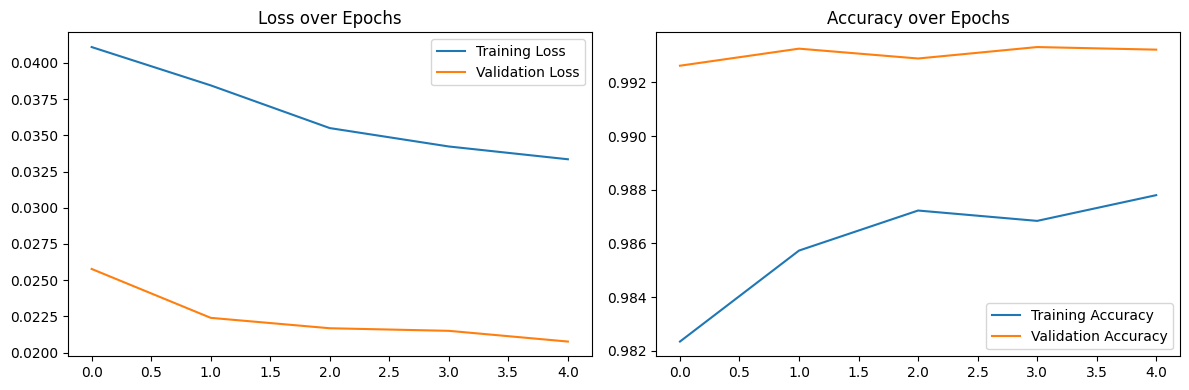

In [4]:
unet_history = unet.fit(
    X_train, y_train,
    batch_size=4,
    epochs=5, 
    validation_data=(X_test, y_test), 
    verbose=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(unet_history.history['loss'], label='Training Loss')
plt.plot(unet_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(unet_history.history['accuracy'], label='Training Accuracy')
plt.plot(unet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


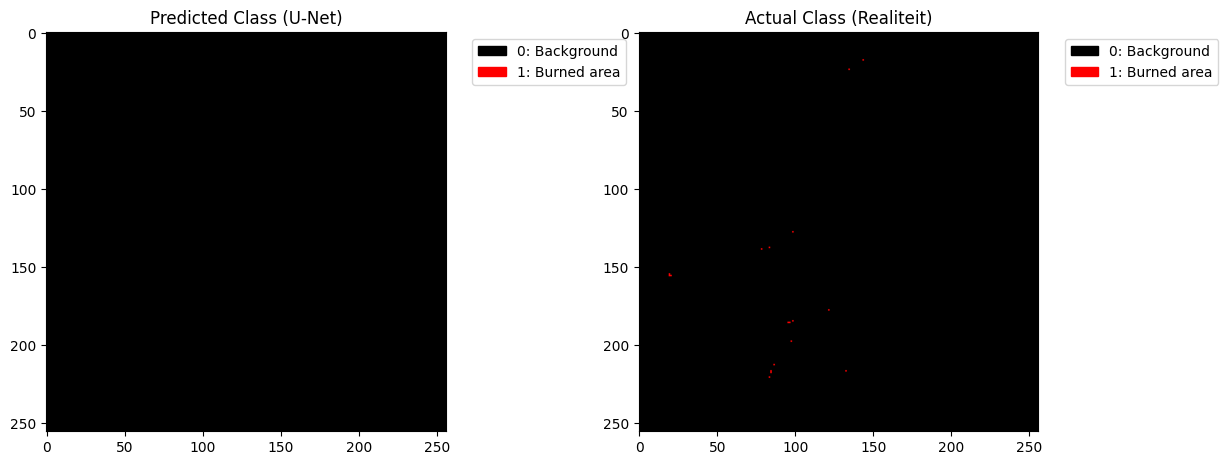

In [5]:
# 50% chance of fire per pixel
X_visual = X_test[0:1] 
y_visual_true = y_test[0]

y_visual_pred = unet.predict(X_visual)
y_visual_pred_class = np.argmax(y_visual_pred, axis=-1)  

predicted_class = y_visual_pred_class[0]  
actual_class = y_visual_true[..., 0] if len(y_visual_true.shape) == 3 else y_visual_true

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(predicted_class, cmap=my_cmap_segTHRawS, vmin=0, vmax=1)
plt.title('Predicted Class (U-Net)')
plt.legend(handles=[box_0_segTHRawS, box_1_segTHRawS], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
plt.imshow(actual_class, cmap=my_cmap_segTHRawS, vmin=0, vmax=1)
plt.title('Actual Class (Realiteit)')
plt.legend(handles=[box_0_segTHRawS, box_1_segTHRawS], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


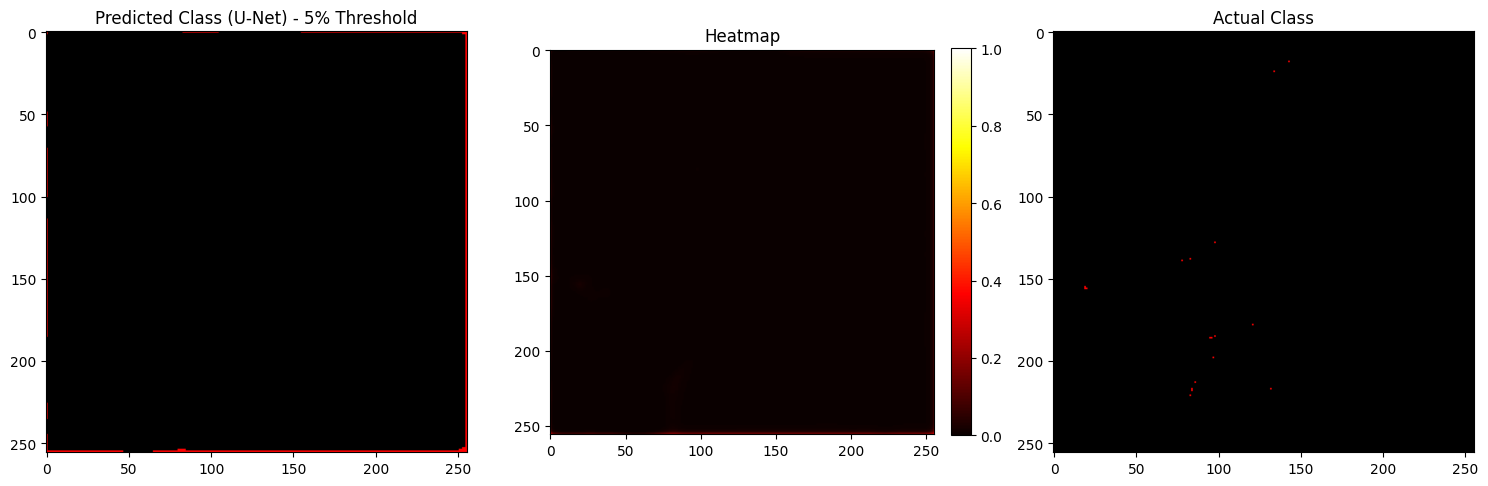

In [6]:
# 5% chance of fire per pixel
X_visual = X_test[0:1] 
y_visual_true = y_test[0]

y_visual_pred = unet.predict(X_visual)

fire_probabilities = y_visual_pred[0, :, :, 1]

actual_class = y_visual_true[..., 0] if len(y_visual_true.shape) == 3 else y_visual_true

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
lower_threshold = (fire_probabilities > 0.05).astype(int)
plt.imshow(lower_threshold, cmap=my_cmap_segTHRawS, vmin=0, vmax=1)
plt.title('Predicted Class (U-Net) - 5% Threshold')

plt.subplot(1, 3, 2)
plt.imshow(fire_probabilities, cmap='hot', vmin=0, vmax=1)
plt.title('Heatmap')
plt.colorbar(fraction=0.046, pad=0.04) 

plt.subplot(1, 3, 3)
plt.imshow(actual_class, cmap=my_cmap_segTHRawS, vmin=0, vmax=1)
plt.title('Actual Class')

plt.tight_layout()
plt.show()

In [8]:
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/SegTHRawS'

all_unet_preds = unet.predict(X_test)

unet_probs = all_unet_preds[..., 1]
unet_predictions = np.argmax(all_unet_preds, axis=-1)

np.save(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_unet.npy'), unet_probs)
np.save(os.path.join(bewerkte_data_dir, 'y_pred_masks_unet.npy'), unet_predictions)
np.save(os.path.join(bewerkte_data_dir, 'y_test_masks_unet.npy'), y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


Here, we can look into dice loss, zodat de F1 score verbeterd kan worden. Heb ik op dit moment geen tijd voor, maar mocht die tijd er wel zijn..